# KDA（Kimi Delta Attention）：gated delta rule

> 线性注意力四章的终点。KDA 把 **GLA 的逐通道衰减门控**（选择性遗忘）和 **DeltaNet 的 delta rule
> 纠错**（定向擦写）**合二为一**，是 Moonshot **Kimi Linear** 的核心。本章讲透它怎么由前两章拼成、
> 数学上如何退化回 DeltaNet/GLA，再逐段读**完整解耦自 fla** 的真实 kernel（四章里最复杂的）。

In [1]:
import sys, math
from pathlib import Path

import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "12-kda")); sys.path.insert(0, str(ROOT / "11-deltanet"))

from common.nbtools import setup_cjk, show_code
setup_cjk()
from kda import kda_recurrent
from deltanet import delta_rule_recurrent   # 用于退化对比

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0))

跑在 NVIDIA GeForce RTX 4090


## 1. 四章演进：差异全在"状态 S 每步怎么更新"

线性注意力把 attention 写成状态递归 `oₜ = qₜ Sₜ`。四章的全部区别就在这一行更新式：

| 章 | 机制 | $S_t =$ | 特点 |
|---|---|---|---|
| 10 | linear attn | $S_{t-1} + k_t v_t^\top$ | 只加不减，键冲突混叠 |
| 10 | **GLA** | $\operatorname{diag}(e^{g_t}) S_{t-1} + k_t v_t^\top$ | 加 per-channel 衰减（选择性遗忘），写入仍只加 |
| 11 | **DeltaNet** | $S_{t-1}(I - \beta_t k_t k_t^\top) + \beta_t v_t k_t^\top$ | delta 纠错（定向擦写），无遗忘 |
| 12 | **KDA** | $\operatorname{diag}(e^{g_t}) S_{t-1} + \beta_t k_t(v_t - \hat v_t)^\top$ | **门控遗忘 + delta 纠错**，二者兼得 |

KDA = GLA（门控）⊕ DeltaNet（纠错）。下面用数学退化验证这个"拼接"关系。

In [2]:
# KDA 有两个旋钮：g（门控遗忘，来自 GLA）+ β（delta 纠错，来自 DeltaNet）
# 当 g=0（exp(g)=1，不遗忘）时，KDA 应**精确退化为 DeltaNet**
B, H, T, D = 2, 2, 128, 64
q = torch.randn(B, H, T, D, device="cuda")
k = torch.randn(B, H, T, D, device="cuda")
v = torch.randn(B, H, T, D, device="cuda")
beta = torch.rand(B, H, T, device="cuda")
g0 = torch.zeros(B, H, T, D, device="cuda")              # g=0 → 不遗忘

o_kda_g0 = kda_recurrent(q, k, v, g0, beta, l2norm=True)
o_delta = delta_rule_recurrent(q, k, v, beta, l2norm=True)
print("KDA(g=0) vs DeltaNet recurrent  max diff:", (o_kda_g0 - o_delta).abs().max().item())
print("→ g=0 时 KDA 精确退化为 DeltaNet（门控关掉，只剩 delta 纠错）。KDA 就是给 DeltaNet 加上了 GLA 的门控。")

KDA(g=0) vs DeltaNet recurrent  max diff: 0.0
→ g=0 时 KDA 精确退化为 DeltaNet（门控关掉，只剩 delta 纠错）。KDA 就是给 DeltaNet 加上了 GLA 的门控。


## 2. KDA = gated delta rule：先门控遗忘，再 delta 纠错

每步两个动作合在一起：

$$\hat S = \operatorname{diag}(e^{g_t})\,S_{t-1}\ \text{(GLA 门控遗忘)},\quad
  S_t = \hat S + \beta_t k_t\,(v_t - \hat S^\top k_t)^\top\ \text{(DeltaNet 纠错)}.$$

`exp(gₜ)`（per-channel）让状态按通道遗忘；`βₜ kₜ(vₜ − v̂ₜ)ᵀ` 用 kₜ 查询**门控后**的旧状态、定向纠错。
下面看门控强度 g 如何控制"记忆窗口"——g 越负，远期信息衰减越快。

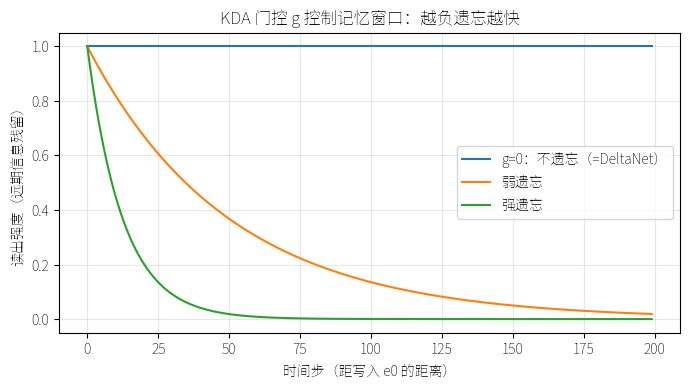

g=0 信息不衰减（DeltaNet 行为）；g<0 按通道指数遗忘（GLA 行为）。KDA 二者兼得。


In [3]:
# 不同门控强度下，KDA 对"远期写入"的保留程度：t=0 写一条信息，看它在后续步的残留强度
T = 200
def memory_trace(g_val):
    q = torch.zeros(1, 1, T, 16, device="cuda"); k = torch.zeros(1, 1, T, 16, device="cuda")
    v = torch.zeros(1, 1, T, 16, device="cuda"); beta = torch.ones(1, 1, T, device="cuda")
    k[0, 0, 0, 0] = 1.0; v[0, 0, 0, 0] = 1.0          # t=0 写 (e0 -> e0)
    q[:, :, :, 0] = 1.0                                # 每步都用 e0 query（不归一化，看原始衰减）
    g = torch.full((1, 1, T, 16), g_val, device="cuda")
    o = kda_recurrent(q, k, v, g, beta, l2norm=False, scale=1.0)
    return o[0, 0, :, 0].detach().cpu().numpy()

plt.figure(figsize=(7, 4))
for gv, name in [(0.0, "g=0：不遗忘（=DeltaNet）"), (-0.02, "弱遗忘"), (-0.08, "强遗忘")]:
    plt.plot(memory_trace(gv), label=name)
plt.xlabel("时间步（距写入 e0 的距离）"); plt.ylabel("读出强度（远期信息残留）")
plt.legend(); plt.title("KDA 门控 g 控制记忆窗口：越负遗忘越快"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("g=0 信息不衰减（DeltaNet 行为）；g<0 按通道指数遗忘（GLA 行为）。KDA 二者兼得。")

## 3. 深度优化版：完整解耦自 fla（四章里最复杂的解耦）

KDA 的 fla kernel 有 **14 个 triton 文件**，朴素依赖闭包 ~27 文件且发散。本仓库完整解耦（计算逻辑
一字未改），靠**三招**收敛（详见 `SOURCES.md`）：

1. **no-op dispatch** 绕过后端分派（CP / TileLang）；
2. **cp stub** 绕过多卡 context-parallel（KDA 的 chunk_fwd/bwd 直接 import 它，单卡 `cp_context=None`
   不用 → `_fla_kda_compat.py` 把 `FLACPContext` 和几个 pre_process 函数 stub 成占位）；
3. **复用 gla.chunk**（KDA 借 GLA 的输出函数 `chunk_gla_fwd_o_gk`）。

下面展示入口主 kernel 源码（暗色，适配深色编辑器）：

In [4]:
show_code(str(ROOT / "12-kda" / "_fla_kda_chunk.py"))

### 逐段读懂 + 门控 kernel

KDA chunk-parallel 把 gated delta 拆成（与 DeltaNet 同框架，多了门控）：
1. **门控累积**（`_fla_kda_gate` / cumsum）：per-channel log-decay 的块内 prefix-sum；
2. **WY 表示**（`_fla_kda_wy_fast`）：delta 的下三角求逆（同 DeltaNet）；
3. **块间状态**（`_fla_kda_chunk_delta_h`）：带门控衰减的状态递归；
4. **块内**（`_fla_kda_chunk_intra`，最大的 kernel）+ **输出**（复用 `gla.chunk` 的 `chunk_gla_fwd_o_gk`）。

> cp stub：`chunk_fwd/bwd` 静态 import 了多卡 context-parallel 的预处理函数，但单卡 `cp_context=None`
> 的分支不会调用它们；解耦时 stub 成"调用即报错"的占位，既不影响单卡计算、又把多卡代码挡在闭包外。

门控 kernel 源码：

In [5]:
show_code(str(ROOT / "12-kda" / "_fla_kda_gate.py"))

### 验证：解耦没改任何计算

定长 + 变长（cu_seqlens），本地解耦 kernel 与 fla 原版近 bitwise 一致；并与简要版 recurrent 对齐。
KDA 需 `use_qk_l2norm_in_kernel=True`（delta rule 标配）。

In [6]:
from _fla_kda_chunk import chunk_kda as local
B, T, H, D = 2, 512, 4, 64
gg = torch.Generator("cuda").manual_seed(1)
q = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
k = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
v = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
g = F.logsigmoid(torch.randn(B, T, H, D, device="cuda", dtype=torch.float32, generator=gg))
beta = torch.rand(B, T, H, device="cuda", dtype=torch.bfloat16, generator=gg)

ol, _ = local(q, k, v, g, beta, use_qk_l2norm_in_kernel=True)
try:
    from fla.ops.kda import chunk_kda as flak
    of, _ = flak(q, k, v, g, beta, use_qk_l2norm_in_kernel=True)
    print("① 定长：本地解耦 vs fla 原版   max diff:", (ol.float() - of.float()).abs().max().item())
    cu = torch.tensor([0, 200, 512, 800, 1024], device="cuda", dtype=torch.int32)
    qp, kp, vp, gp = (x.reshape(1, B * T, H, D) for x in (q, k, v, g)); bp = beta.reshape(1, B * T, H)
    o2, _ = local(qp, kp, vp, gp, bp, use_qk_l2norm_in_kernel=True, cu_seqlens=cu)
    f2, _ = flak(qp, kp, vp, gp, bp, use_qk_l2norm_in_kernel=True, cu_seqlens=cu)
    print("② 变长(cu_seqlens)：本地 vs fla    max diff:", (o2.float() - f2.float()).abs().max().item())
except ImportError:
    print("（未装 fla，跳过原版对照）")

o_rec = kda_recurrent(*(x.transpose(1, 2) for x in (q, k, v, g)), beta.transpose(1, 2), l2norm=True).transpose(1, 2)
print("③ 本地 chunk vs 简要版 recurrent   max diff:", (ol.float() - o_rec.float()).abs().max().item())
print("→ 完整解耦（14 文件 + cp stub）没改任何计算：与 fla bitwise 一致、与 recurrent ground truth 对齐。")

① 定长：本地解耦 vs fla 原版   max diff: 0.0


② 变长(cu_seqlens)：本地 vs fla    max diff: 0.0
③ 本地 chunk vs 简要版 recurrent   max diff: 0.0008866786956787109
→ 完整解耦（14 文件 + cp stub）没改任何计算：与 fla bitwise 一致、与 recurrent ground truth 对齐。


## 4. 收尾：线性注意力线（10→11→12）完成

- **linear attention**：结合律把 O(S²) 变 O(S)，但状态只加不减；
- **GLA**：加 per-channel 衰减门控（选择性遗忘）；
- **DeltaNet**：加 delta rule 纠错（定向擦写）；
- **KDA**：门控 + 纠错合一（gated delta rule），Kimi Linear 的核心。

四章的深度优化版都来自 fla，且都**完整解耦脱离 fla**（10 GLA 3 文件 → 11 DeltaNet 8 文件 →
12 KDA 14 文件），用 no-op dispatch / cp stub 把发散的依赖闭包收敛到纯 triton 核心，与原版 bitwise 一致。